#imports and read data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , classification_report
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer



In [2]:
# import kagglehub
#
# path = kagglehub.dataset_download("naeem41/cicids2017-dataset")
#
# print("Path to dataset files:", path)

In [3]:
# import os
#
# for root, dirs, files in os.walk(path):
#     for file in files:
#         print(os.path.join(root, file))

In [4]:
df_data = pd.read_csv("combinenew.csv")
df_data.shape

(2830744, 79)

In [5]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [47]:
df_data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count'

#preprocessing

In [6]:
df_data.info(show_counts=True)
# Target => Label => Str
# Destination Port => Object
# Remaining Data => Float

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             2830744 non-null  object 
 1    Flow Duration                2830743 non-null  float64
 2    Total Fwd Packets            2830743 non-null  float64
 3    Total Backward Packets       2830743 non-null  float64
 4   Total Length of Fwd Packets   2830743 non-null  float64
 5    Total Length of Bwd Packets  2830743 non-null  float64
 6    Fwd Packet Length Max        2830743 non-null  float64
 7    Fwd Packet Length Min        2830743 non-null  float64
 8    Fwd Packet Length Mean       2830743 non-null  float64
 9    Fwd Packet Length Std        2830743 non-null  float64
 10  Bwd Packet Length Max         2830743 non-null  float64
 11   Bwd Packet Length Min        2830743 non-null  float64
 12   Bwd Packet Length Mean     

In [7]:
df_data.describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,8.708495e+02,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,1.946367e+03,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,7.900000e+01,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,2.800000e+02,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,1.953000e+04,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [8]:
df_data = df_data.round(2) #to show off more duplicates

In [9]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


##duplicates

In [10]:
df_data.duplicated().sum()

np.int64(330513)

In [11]:
def get_duplicate_columns(df):
    duplicate_column_names = set()

    # Iterate through all columns
    for x in range(df.shape[1]):
        col_x = df.iloc[:, x]

        for y in range(x + 1, df.shape[1]):
            col_y = df.iloc[:, y]

            # If the columns are completely identical, flag the second one for removal
            if col_x.equals(col_y):
                duplicate_column_names.add(df.columns.values[y])

    return list(duplicate_column_names)

# Get the list of duplicate columns
cols_to_drop = get_duplicate_columns(df_data)
print(f"Duplicate columns found: {cols_to_drop}")

df_data = df_data.drop(columns=cols_to_drop) #drop identical cols

Duplicate columns found: [' Avg Fwd Segment Size', ' Fwd Avg Packets/Bulk', ' Bwd Avg Bytes/Bulk', ' CWE Flag Count', 'Bwd Avg Bulk Rate', ' Fwd Header Length.1', ' Bwd URG Flags', ' Subflow Bwd Packets', ' Bwd Avg Packets/Bulk', ' Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Bulk Rate', ' SYN Flag Count']


In [12]:
df_data.drop_duplicates(inplace=True) # Drop Duplicates

df_data.duplicated().sum() # Check Again

np.int64(0)

In [13]:
df_data.shape # The Shape Data After Drop Duplicates

(2500231, 65)

##missing vals

In [14]:
df_data.replace([np.inf, -np.inf], np.nan, inplace=True)
df_data.replace(['?', 'unknown', 'Unknown', 'UNKNOWN', 'None', 'none', ' '], np.nan, inplace=True)
print(df_data.isnull().sum().to_string())

 Destination Port                  0
 Flow Duration                     1
 Total Fwd Packets                 1
 Total Backward Packets            1
Total Length of Fwd Packets        1
 Total Length of Bwd Packets       1
 Fwd Packet Length Max             1
 Fwd Packet Length Min             1
 Fwd Packet Length Mean            1
 Fwd Packet Length Std             1
Bwd Packet Length Max              1
 Bwd Packet Length Min             1
 Bwd Packet Length Mean            1
 Bwd Packet Length Std             1
Flow Bytes/s                    1542
 Flow Packets/s                 1538
 Flow IAT Mean                     1
 Flow IAT Std                      1
 Flow IAT Max                      1
 Flow IAT Min                      1
Fwd IAT Total                      1
 Fwd IAT Mean                      1
 Fwd IAT Std                       1
 Fwd IAT Max                       1
 Fwd IAT Min                       1
Bwd IAT Total                      1
 Bwd IAT Mean                      1
 

In [15]:
df_data.dropna(inplace=True)
# Check
print(df_data.isnull().sum().to_string())

 Destination Port               0
 Flow Duration                  0
 Total Fwd Packets              0
 Total Backward Packets         0
Total Length of Fwd Packets     0
 Total Length of Bwd Packets    0
 Fwd Packet Length Max          0
 Fwd Packet Length Min          0
 Fwd Packet Length Mean         0
 Fwd Packet Length Std          0
Bwd Packet Length Max           0
 Bwd Packet Length Min          0
 Bwd Packet Length Mean         0
 Bwd Packet Length Std          0
Flow Bytes/s                    0
 Flow Packets/s                 0
 Flow IAT Mean                  0
 Flow IAT Std                   0
 Flow IAT Max                   0
 Flow IAT Min                   0
Fwd IAT Total                   0
 Fwd IAT Mean                   0
 Fwd IAT Std                    0
 Fwd IAT Max                    0
 Fwd IAT Min                    0
Bwd IAT Total                   0
 Bwd IAT Mean                   0
 Bwd IAT Std                    0
 Bwd IAT Max                    0
 Bwd IAT Min  

Remove Zero-Variance Columns

Note: these columns are almost always 0, so they carry no signal. This is a low-variance issue, not data leakage.

In [16]:
df_data.columns = df_data.columns.str.strip()
col_zero = ["Bwd PSH Flags","Fwd URG Flags"]
zero_pct = (df_data[col_zero].replace(0, np.nan).isnull().sum() / len(df_data)) * 100
print(zero_pct)


Bwd PSH Flags    100.000000
Fwd URG Flags     99.996798
dtype: float64


In [17]:
df_data.drop(columns=col_zero, inplace=True)
print("Shape:", df_data.shape)

Shape: (2498689, 63)


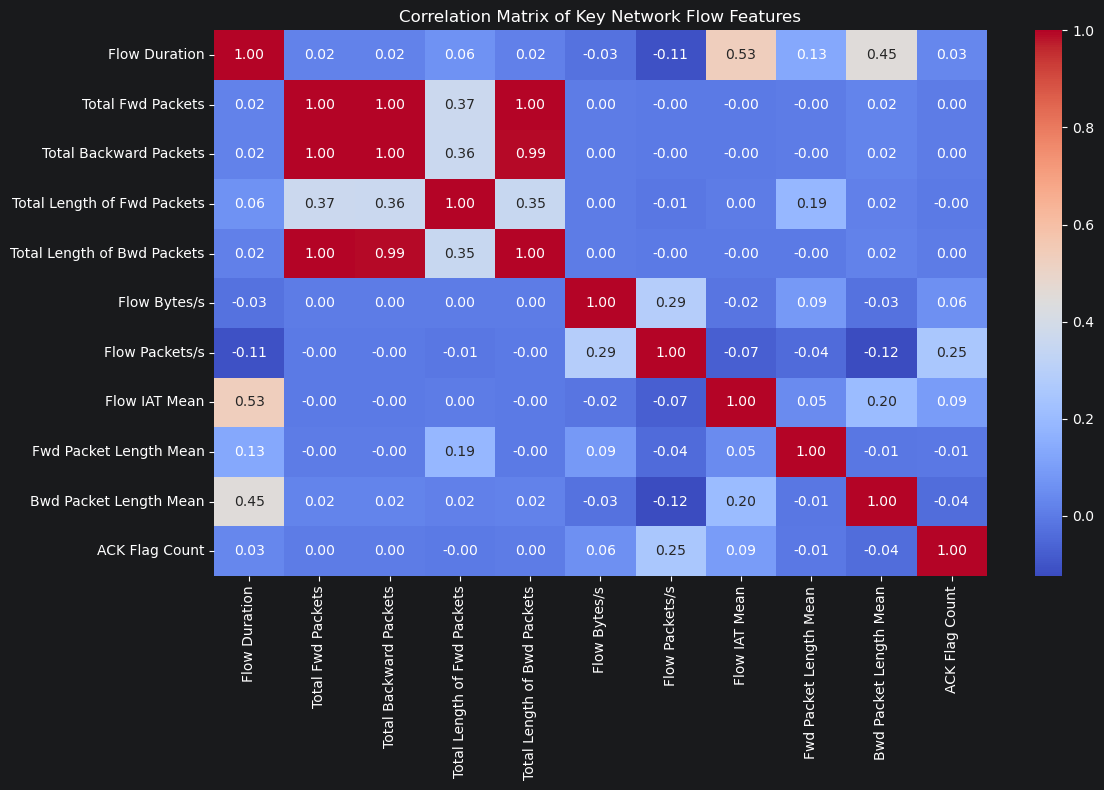

In [18]:
# Check Heatmap Again
key_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'ACK Flag Count'
]
plt.figure(figsize=(12, 8))
corr = df_data[key_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Key Network Flow Features")
plt.tight_layout()
plt.show()

will imput after splitting

In [19]:
non_negative_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'min_seg_size_forward', 'act_data_pkt_fwd',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
non_negative_cols = [c for c in non_negative_cols if c in df_data.columns]

bad_row_mask = (df_data[non_negative_cols] < 0).any(axis=1)
bad_row_mask.sum() #number of invalid negative vals in columns

np.int64(2915)

In [20]:
df_data[non_negative_cols] = df_data[non_negative_cols].mask(
    df_data[non_negative_cols] < 0
)

In [21]:
df_data[non_negative_cols].isna().sum()

Flow Duration                   107
Total Fwd Packets                 0
Total Backward Packets            0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Fwd Packet Length Max             0
Fwd Packet Length Min             0
Fwd Packet Length Mean            0
Fwd Packet Length Std             0
Bwd Packet Length Max             0
Bwd Packet Length Min             0
Bwd Packet Length Mean            0
Bwd Packet Length Std             0
Flow Bytes/s                     78
Flow Packets/s                  107
Flow IAT Mean                   107
Flow IAT Std                      0
Flow IAT Max                    107
Flow IAT Min                   2880
Fwd IAT Total                     0
Fwd IAT Mean                      0
Fwd IAT Std                       0
Fwd IAT Max                       0
Fwd IAT Min                      17
Bwd IAT Total                     0
Bwd IAT Mean                      0
Bwd IAT Std                       0
Bwd IAT Max                 

In [22]:
df_data.shape

(2498689, 63)

## EDA

##class distrbution

In [23]:
label_counts = df_data['Label'].value_counts()
label_percentage = df_data['Label'].value_counts(normalize=True) * 100

distribution = pd.DataFrame({'Count': label_counts, 'Percentage': label_percentage.round(3)})
print(distribution)

                            Count  Percentage
Label                                        
BENIGN                    2073000      82.964
DoS Hulk                   172792       6.915
DDoS                       128016       5.123
PortScan                    90694       3.630
DoS GoldenEye               10286       0.412
FTP-Patator                  5931       0.237
DoS slowloris                5385       0.216
DoS Slowhttptest             5228       0.209
SSH-Patator                  3219       0.129
Bot                          1948       0.078
Web Attack_Brute Force       1470       0.059
Web Attack_XSS                652       0.026
Infiltration                   36       0.001
Web Attack_Sql Injection       21       0.001
Heartbleed                     11       0.000


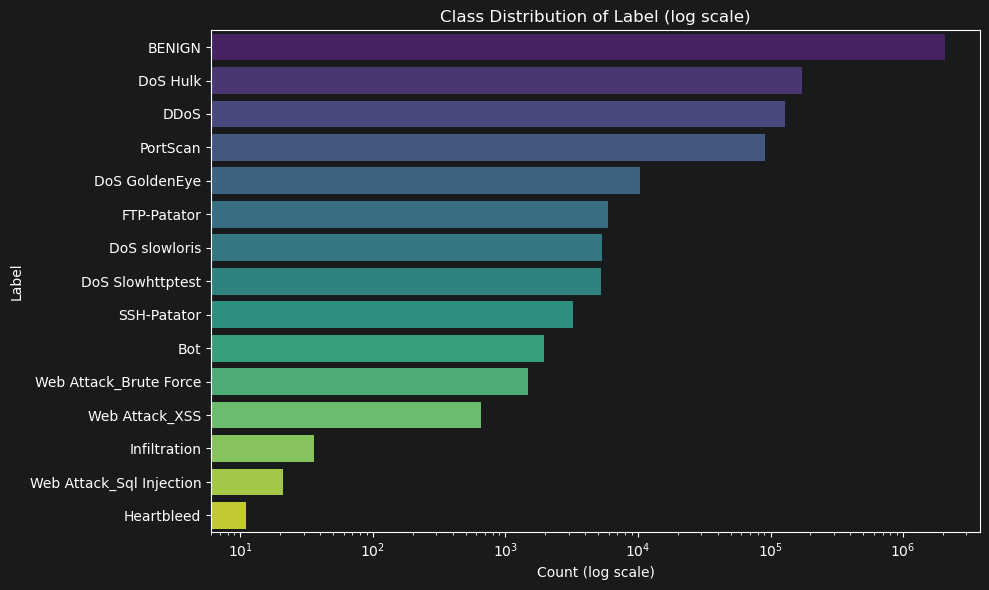

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('Label')
plt.title('Class Distribution of Label (log scale)')
plt.tight_layout()
plt.show()

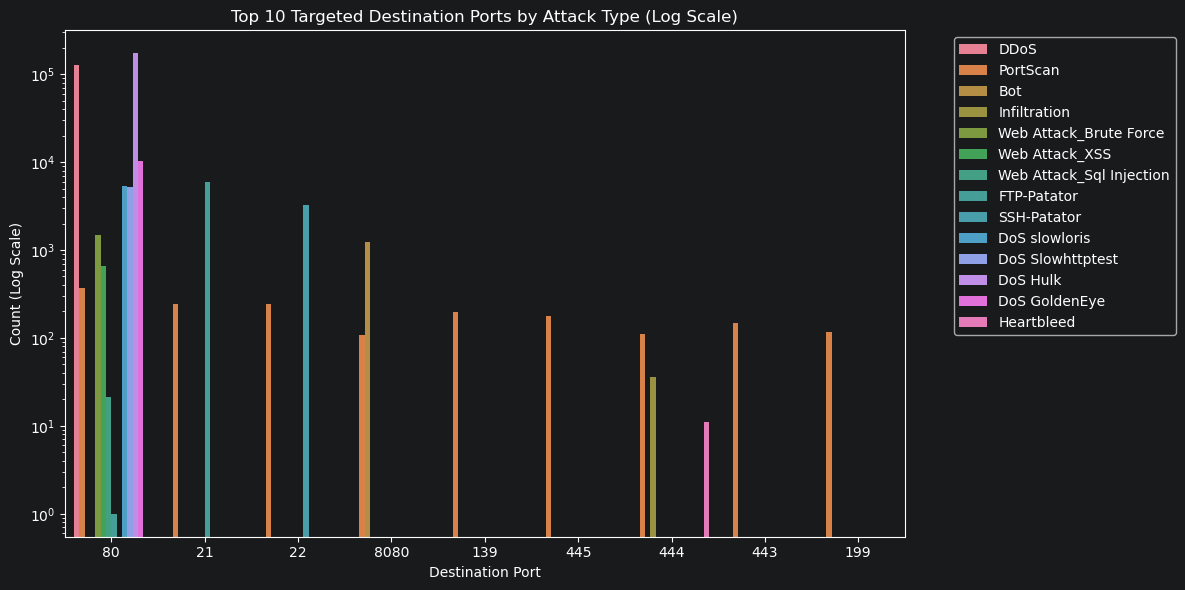

In [25]:
attack_df = df_data[df_data['Label'] != 'BENIGN']
top_ports = attack_df['Destination Port'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=attack_df[attack_df['Destination Port'].isin(top_ports)],
    x='Destination Port',
    hue='Label',
    order=top_ports
)
plt.yscale('log')
plt.title('Top 10 Targeted Destination Ports by Attack Type (Log Scale)')
plt.xlabel('Destination Port')
plt.ylabel('Count (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

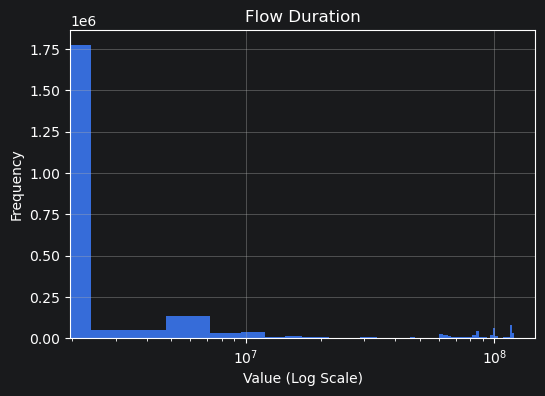

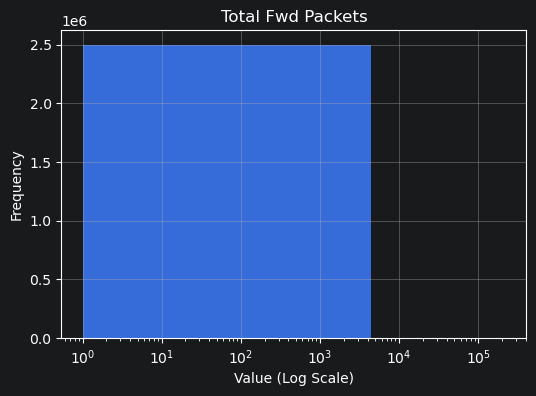

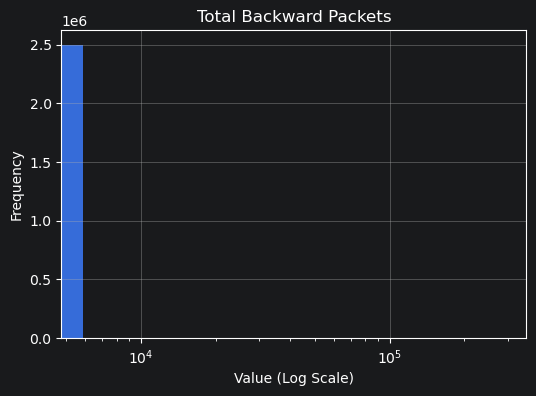

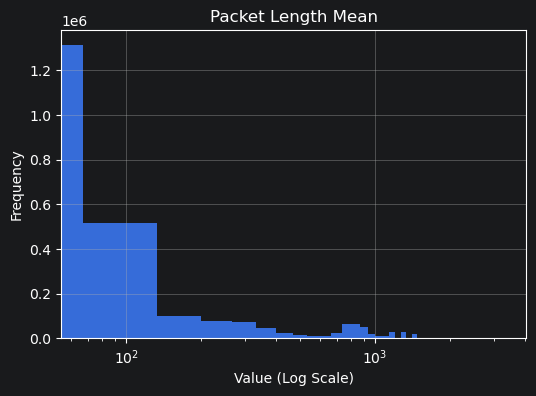

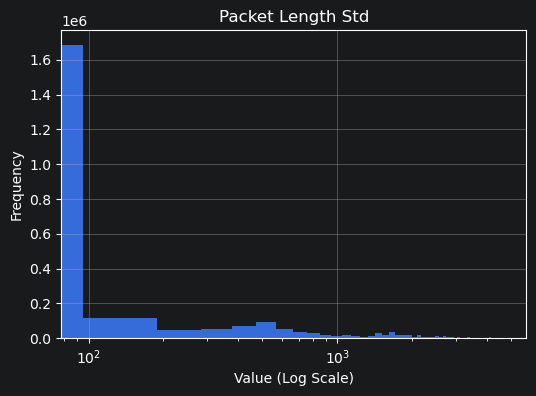

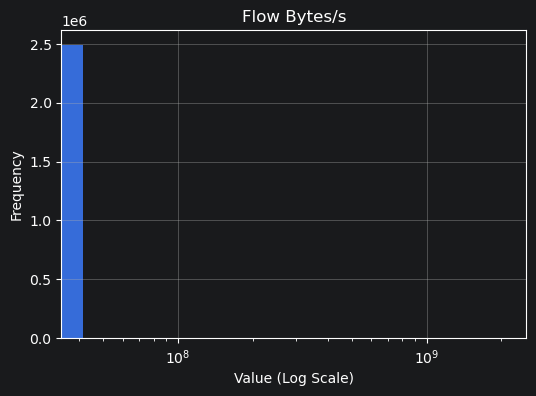

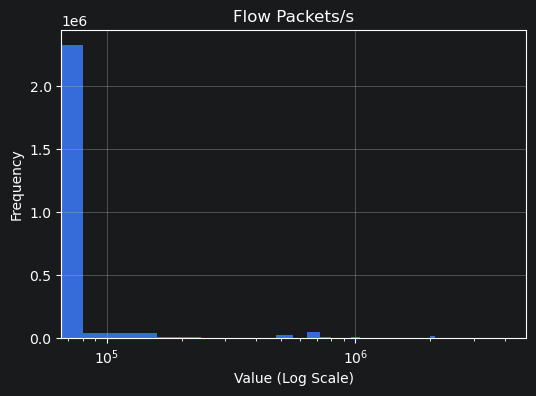

In [26]:
columns = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Packet Length Mean', 'Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s'
]

# Loop through each column to create individual, correctly formatted plots
for col in columns:
    plt.figure(figsize=(6, 4))
    df_data[col].hist(bins=50)
    plt.xscale('log')
    plt.title(col)  # Dynamically sets the correct title for each column
    plt.xlabel('Value (Log Scale)')
    plt.ylabel('Frequency')
    plt.show()


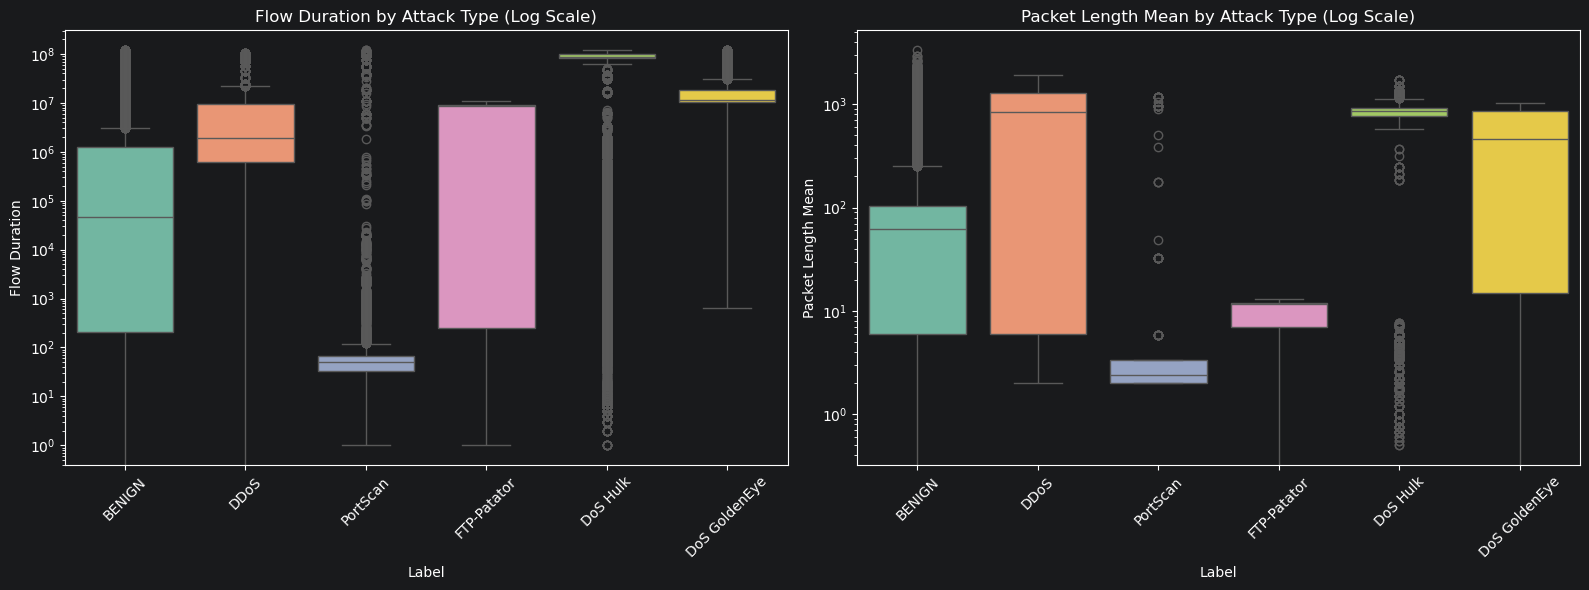

In [27]:
top_labels = df_data['Label'].value_counts().head(6).index
df_subset = df_data[df_data['Label'].isin(top_labels)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], data=df_subset, x='Label', y='Flow Duration', palette='Set2')
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration by Attack Type (Log Scale)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(ax=axes[1], data=df_subset, x='Label', y='Packet Length Mean', palette='Set2')
axes[1].set_yscale('log')
axes[1].set_title('Packet Length Mean by Attack Type (Log Scale)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

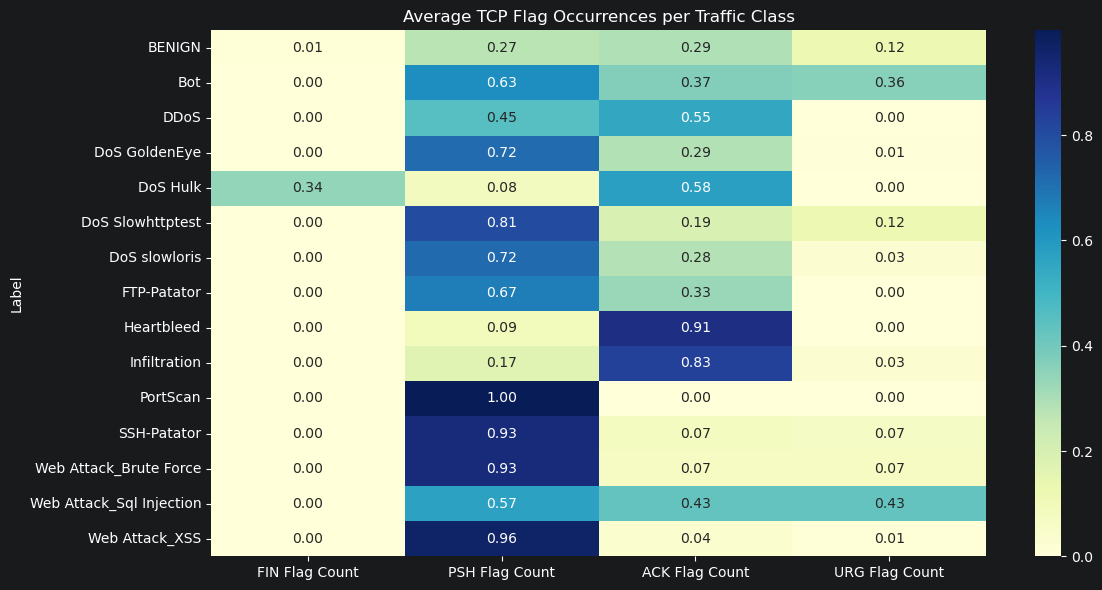

In [28]:
flag_cols = ['FIN Flag Count','PSH Flag Count', 'ACK Flag Count', 'URG Flag Count']
flag_summary = df_data.groupby('Label')[flag_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(flag_summary, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average TCP Flag Occurrences per Traffic Class")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

##multiclass to binary

In [29]:
df_data['Binary_Label'] = df_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

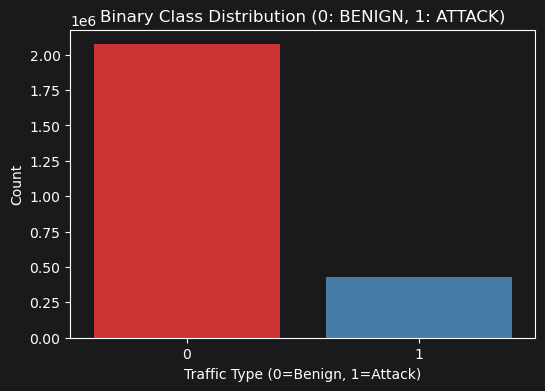

In [30]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_data, x='Binary_Label', palette='Set1', hue='Binary_Label', legend=False)
plt.title('Binary Class Distribution (0: BENIGN, 1: ATTACK)')
plt.xlabel('Traffic Type (0=Benign, 1=Attack)')
plt.ylabel('Count')
plt.show()

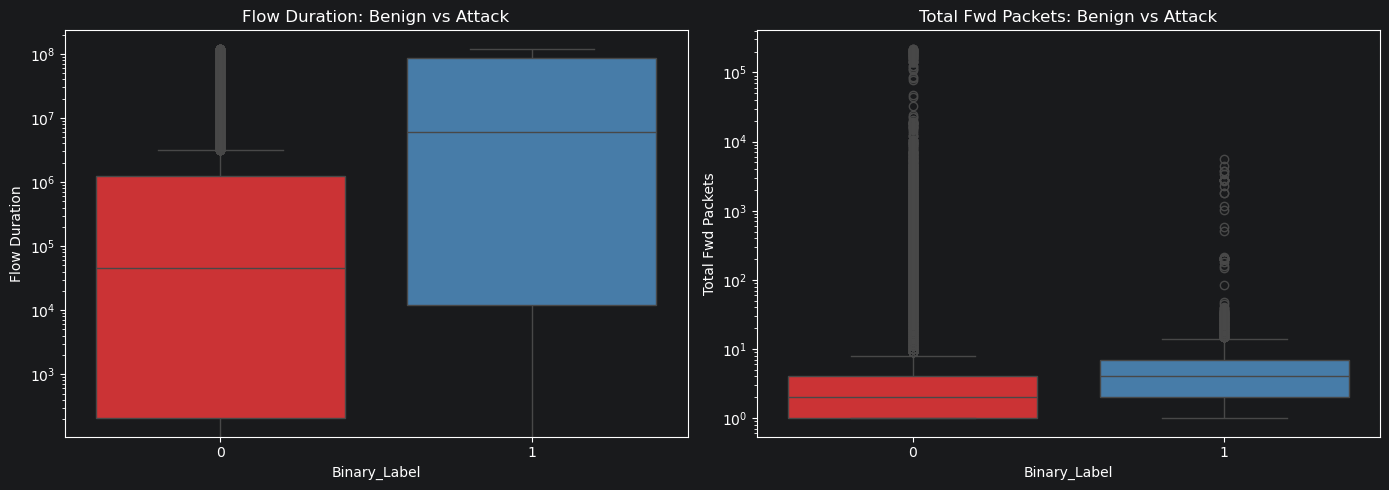

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], data=df_data, x='Binary_Label', y='Flow Duration', palette='Set1')
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration: Benign vs Attack')

sns.boxplot(ax=axes[1], data=df_data, x='Binary_Label', y='Total Fwd Packets', palette='Set1')
axes[1].set_yscale('log')
axes[1].set_title('Total Fwd Packets: Benign vs Attack')

plt.tight_layout()
plt.show()

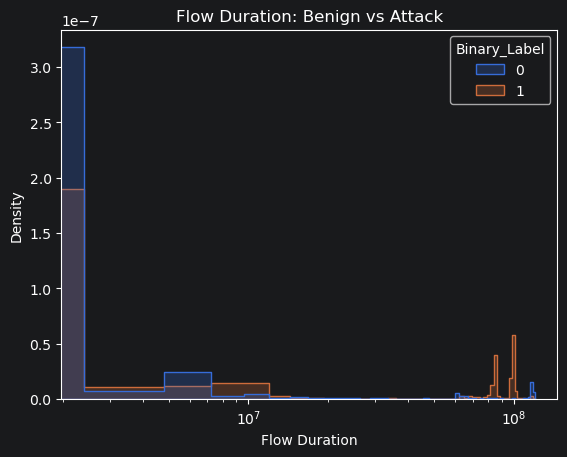

In [32]:
sns.histplot(
    data=df_data,
    x='Flow Duration',
    hue='Binary_Label',
    bins=50,
    element='step',
    stat='density',
    common_norm=False
)

plt.xscale('log')
plt.title('Flow Duration: Benign vs Attack')
plt.show()

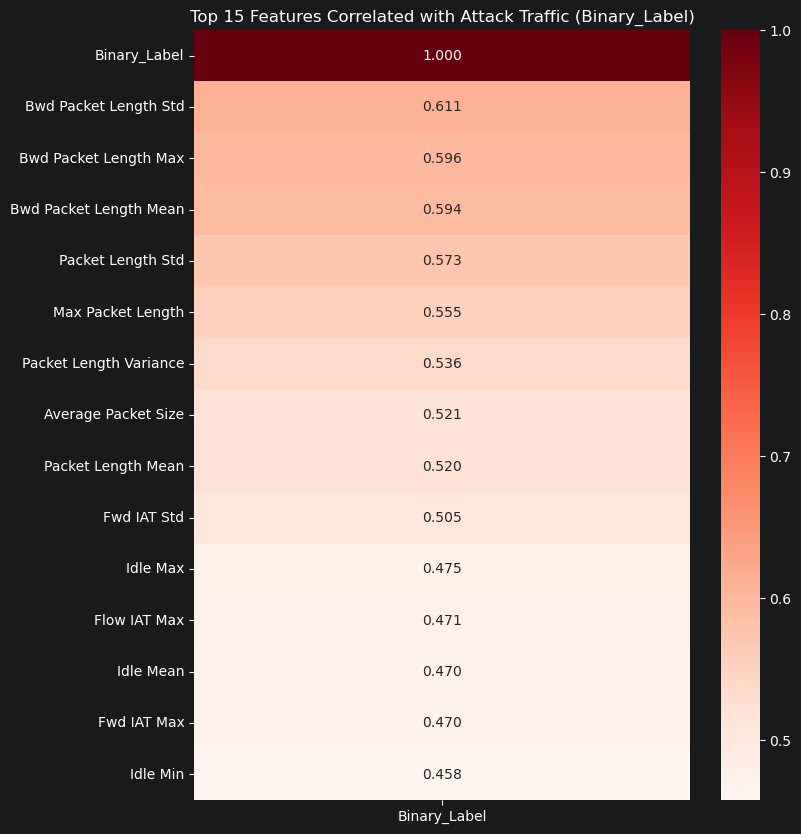

In [33]:
plt.figure(figsize=(8, 10))
# dropping string and multi class target to calculate correlation properly
binary_corr = df_data.drop(columns=['Label']).corr()[['Binary_Label']].sort_values(by='Binary_Label', ascending=False)
sns.heatmap(binary_corr.head(15), annot=True, cmap='Reds', fmt='.3f')
plt.title("Top 15 Features Correlated with Attack Traffic (Binary_Label)")
plt.show()

#split

In [34]:
df_data = df_data.sample(frac=0.25, random_state=42)

In [35]:
X = df_data.drop(columns=['Label','Binary_Label','RST Flag Count','Destination Port'], errors='ignore')
y = df_data['Binary_Label']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

#imputer

In [36]:
non_numeric = X_train.select_dtypes(include=['object']).columns.tolist()
print("Non-numeric columns:", non_numeric)

print("Total NaN values:", X_train.isna().sum().sum())

print("Total Inf values:", np.isinf(X_train.select_dtypes(include=np.number)).values.sum())

Non-numeric columns: []
Total NaN values: 693
Total Inf values: 0


In [37]:
imputer = SimpleImputer(strategy='median')

X_train[non_negative_cols] = imputer.fit_transform(
    X_train[non_negative_cols]
)

X_test[non_negative_cols] = imputer.transform(
    X_test[non_negative_cols]
)

In [38]:
print("Total NaN values:", X_train.isna().sum().sum())

Total NaN values: 0


#Feature selection

In [39]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
).sort_values(ascending=False)

selected_features = mi_scores.head(40).index

X_train = X_train[selected_features]
X_test = X_test[selected_features]

In [40]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)


print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nTest set (UNCHANGED):")
print(y_test.value_counts())

Before SMOTE:
Binary_Label
0    414412
1     85325
Name: count, dtype: int64

After SMOTE:
Binary_Label
1    414412
0    414412
Name: count, dtype: int64

Test set (UNCHANGED):
Binary_Label
0    103604
1     21331
Name: count, dtype: int64


## Modeling

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay
import time
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)

In [43]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
except ImportError:
    pass

try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(random_state=42, n_jobs=-1)
except ImportError:
    pass

#### Evaluation function used for any model type

In [44]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_train_proba = model.decision_function(X_train)
        y_test_proba = model.decision_function(X_test)
    else:
        y_train_proba = y_train_pred
        y_test_proba = y_test_pred

    # Naming convention kept consistent everywhere downstream: Train_<Metric> / Test_<Metric>
    results = {
        "Model": name,
        "Train_Accuracy": accuracy_score(y_train, y_train_pred),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Train_Precision": precision_score(y_train, y_train_pred),
        "Test_Precision": precision_score(y_test, y_test_pred),
        "Train_Recall": recall_score(y_train, y_train_pred),
        "Test_Recall": recall_score(y_test, y_test_pred),
        "Train_F1": f1_score(y_train, y_train_pred),
        "Test_F1": f1_score(y_test, y_test_pred),
        "Train_ROC_AUC": roc_auc_score(y_train, y_train_proba),
        "Test_ROC_AUC": roc_auc_score(y_test, y_test_proba),
        "Train_Time_sec": train_time
    }

    print(f"\n===== {name} =====")
    print("--- Train Classification Report ---")
    print(classification_report(y_train, y_train_pred))
    print("--- Test Classification Report ---")
    print(classification_report(y_test, y_test_pred))
    print(f"Train ROC-AUC: {results['Train_ROC_AUC']:.4f} | Test ROC-AUC: {results['Test_ROC_AUC']:.4f}")
    gap = results["Train_F1"] - results["Test_F1"]
    print(f"Train-Test F1 gap: {gap:.4f} (large gap may indicate overfitting)")

    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues')
    plt.title(f"Confusion Matrix (Test) - {name}")
    plt.show()

    return results, model



===== Logistic Regression =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.87      0.87    414412
           1       0.87      0.88      0.87    414412

    accuracy                           0.87    828824
   macro avg       0.87      0.87      0.87    828824
weighted avg       0.87      0.87      0.87    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.87      0.92    103604
           1       0.57      0.88      0.69     21331

    accuracy                           0.87    124935
   macro avg       0.77      0.87      0.81    124935
weighted avg       0.90      0.87      0.88    124935

Train ROC-AUC: 0.9663 | Test ROC-AUC: 0.9659
Train-Test F1 gap: 0.1798 (large gap may indicate overfitting)


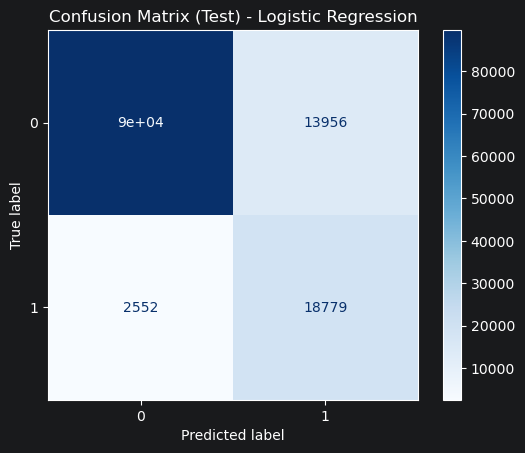


===== Decision Tree =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    414412
           1       1.00      1.00      1.00    414412

    accuracy                           1.00    828824
   macro avg       1.00      1.00      1.00    828824
weighted avg       1.00      1.00      1.00    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103604
           1       0.99      1.00      0.99     21331

    accuracy                           1.00    124935
   macro avg       1.00      1.00      1.00    124935
weighted avg       1.00      1.00      1.00    124935

Train ROC-AUC: 1.0000 | Test ROC-AUC: 0.9976
Train-Test F1 gap: 0.0057 (large gap may indicate overfitting)


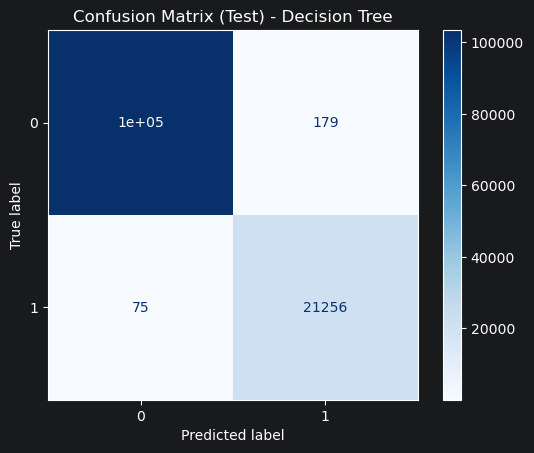


===== Random Forest =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    414412
           1       1.00      1.00      1.00    414412

    accuracy                           1.00    828824
   macro avg       1.00      1.00      1.00    828824
weighted avg       1.00      1.00      1.00    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103604
           1       0.99      1.00      0.99     21331

    accuracy                           1.00    124935
   macro avg       1.00      1.00      1.00    124935
weighted avg       1.00      1.00      1.00    124935

Train ROC-AUC: 1.0000 | Test ROC-AUC: 0.9998
Train-Test F1 gap: 0.0055 (large gap may indicate overfitting)


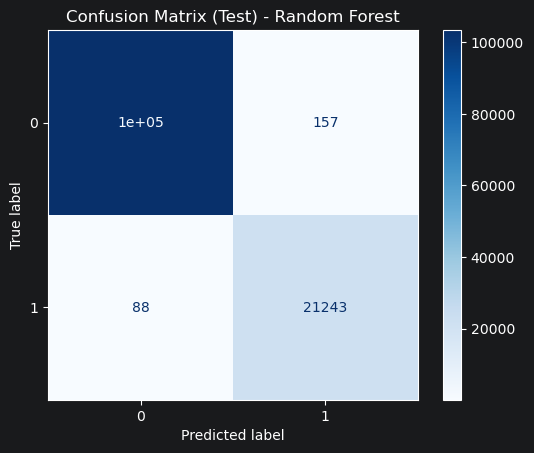


===== Gradient Boosting =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    414412
           1       1.00      0.98      0.99    414412

    accuracy                           0.99    828824
   macro avg       0.99      0.99      0.99    828824
weighted avg       0.99      0.99      0.99    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103604
           1       0.98      0.98      0.98     21331

    accuracy                           0.99    124935
   macro avg       0.99      0.99      0.99    124935
weighted avg       0.99      0.99      0.99    124935

Train ROC-AUC: 0.9994 | Test ROC-AUC: 0.9993
Train-Test F1 gap: 0.0080 (large gap may indicate overfitting)


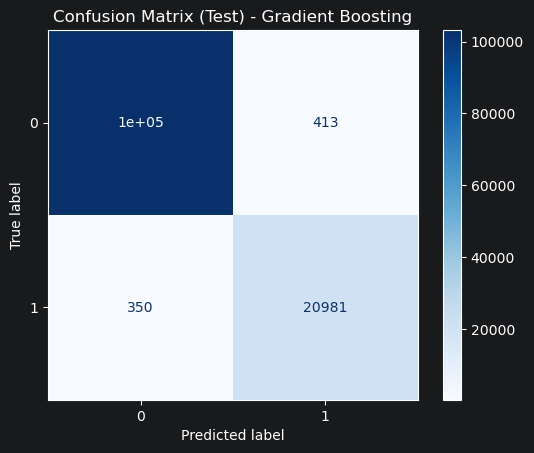


===== AdaBoost =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    414412
           1       0.98      0.98      0.98    414412

    accuracy                           0.98    828824
   macro avg       0.98      0.98      0.98    828824
weighted avg       0.98      0.98      0.98    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    103604
           1       0.93      0.98      0.95     21331

    accuracy                           0.98    124935
   macro avg       0.96      0.98      0.97    124935
weighted avg       0.98      0.98      0.98    124935

Train ROC-AUC: 0.9972 | Test ROC-AUC: 0.9969
Train-Test F1 gap: 0.0289 (large gap may indicate overfitting)


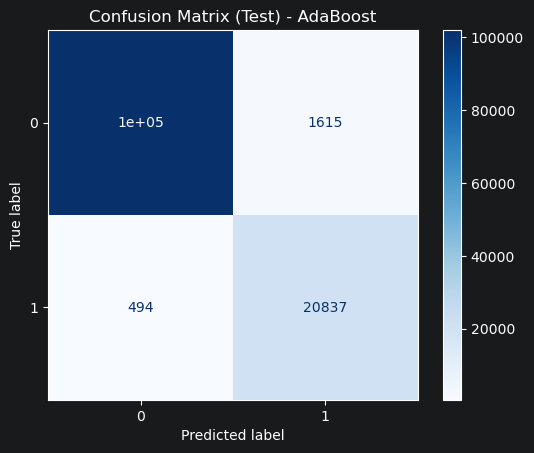


===== KNN =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    414412
           1       1.00      1.00      1.00    414412

    accuracy                           1.00    828824
   macro avg       1.00      1.00      1.00    828824
weighted avg       1.00      1.00      1.00    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103604
           1       0.99      1.00      0.99     21331

    accuracy                           1.00    124935
   macro avg       0.99      1.00      0.99    124935
weighted avg       1.00      1.00      1.00    124935

Train ROC-AUC: 0.9998 | Test ROC-AUC: 0.9979
Train-Test F1 gap: 0.0081 (large gap may indicate overfitting)


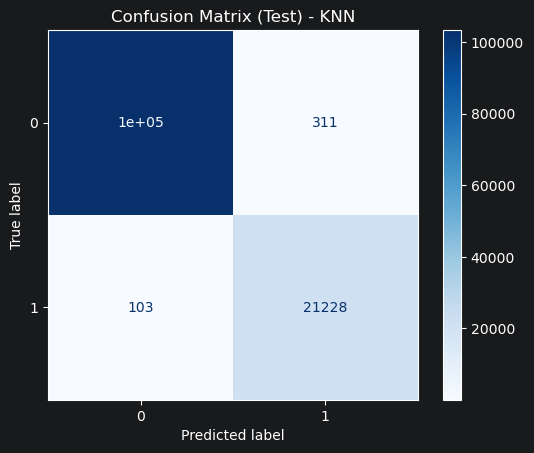


===== Naive Bayes =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.19      0.32    414412
           1       0.55      0.98      0.70    414412

    accuracy                           0.59    828824
   macro avg       0.73      0.59      0.51    828824
weighted avg       0.73      0.59      0.51    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.19      0.32    103604
           1       0.20      0.98      0.33     21331

    accuracy                           0.33    124935
   macro avg       0.59      0.59      0.33    124935
weighted avg       0.85      0.33      0.32    124935

Train ROC-AUC: 0.7597 | Test ROC-AUC: 0.7627
Train-Test F1 gap: 0.3710 (large gap may indicate overfitting)


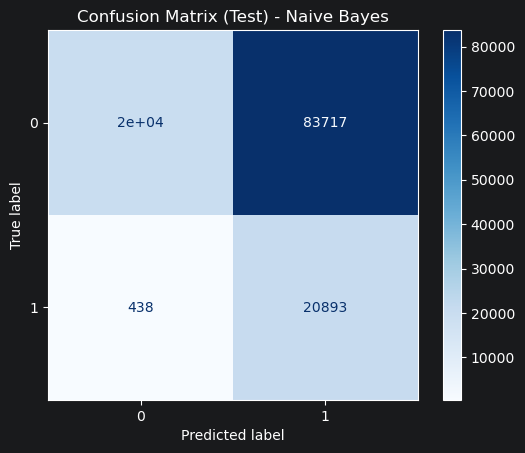


===== XGBoost =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    414412
           1       1.00      1.00      1.00    414412

    accuracy                           1.00    828824
   macro avg       1.00      1.00      1.00    828824
weighted avg       1.00      1.00      1.00    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103604
           1       0.99      1.00      0.99     21331

    accuracy                           1.00    124935
   macro avg       0.99      1.00      1.00    124935
weighted avg       1.00      1.00      1.00    124935

Train ROC-AUC: 1.0000 | Test ROC-AUC: 0.9999
Train-Test F1 gap: 0.0051 (large gap may indicate overfitting)


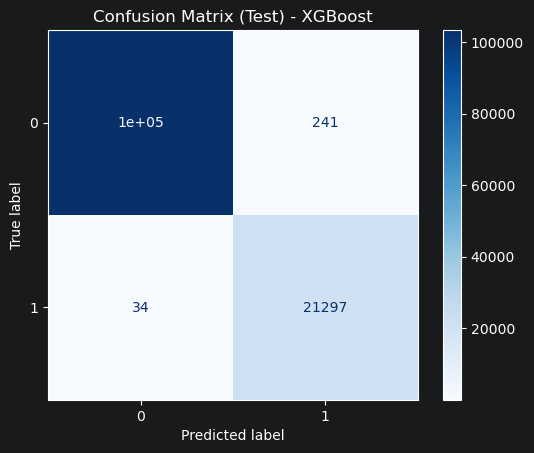

[LightGBM] [Info] Number of positive: 414412, number of negative: 414412
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.080343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10196
[LightGBM] [Info] Number of data points in the train set: 828824, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

===== LightGBM =====
--- Train Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    414412
           1       1.00      1.00      1.00    414412

    accuracy                           1.00    828824
   macro avg       1.00      1.00      1.00    828824
weighted avg       1.00      1.00      1.00    828824

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103604
           1       0.98     

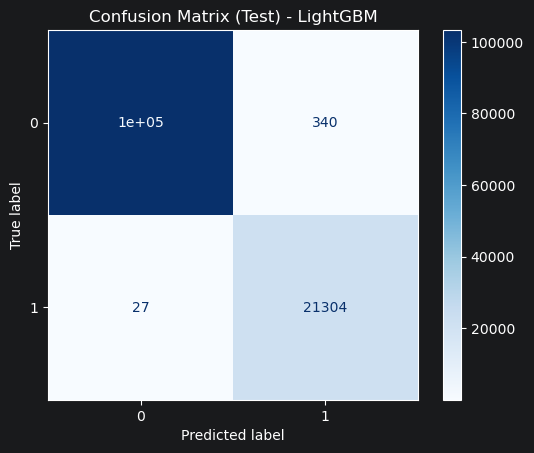

                 Model  Train_Accuracy  Test_Accuracy  Train_Precision  \
2        Random Forest        0.999742       0.998039         0.999496   
1        Decision Tree        0.999742       0.997967         0.999515   
7              XGBoost        0.998662       0.997799         0.997901   
8             LightGBM        0.998121       0.997062         0.997014   
5                  KNN        0.998422       0.996686         0.997689   
3    Gradient Boosting        0.990237       0.993893         0.996149   
4             AdaBoost        0.980745       0.983119         0.983652   
0  Logistic Regression        0.873600       0.867867         0.868627   
6          Naive Bayes        0.585918       0.326410         0.548091   

   Test_Precision  Train_Recall  Test_Recall  Train_F1   Test_F1  \
2        0.992664      0.999988     0.995875  0.999742  0.994266   
1        0.991649      0.999969     0.996484  0.999742  0.994061   
7        0.988810      0.999426     0.998406  0.998663 

In [45]:
results_list = []
trained_models = {}

for name, model in models.items():
    results, trained_model = evaluate_model(
        name, model,
        X_train_smote, y_train_smote,
        X_test_scaled, y_test
    )
    results_list.append(results)
    trained_models[name] = trained_model

# Sorted by Test_F1 (kept consistent with the Train_/Test_ naming from evaluate_model)
results_df = pd.DataFrame(results_list).sort_values(by="Test_F1", ascending=False)
print(results_df)


#### Visual comparison of all models across metrics

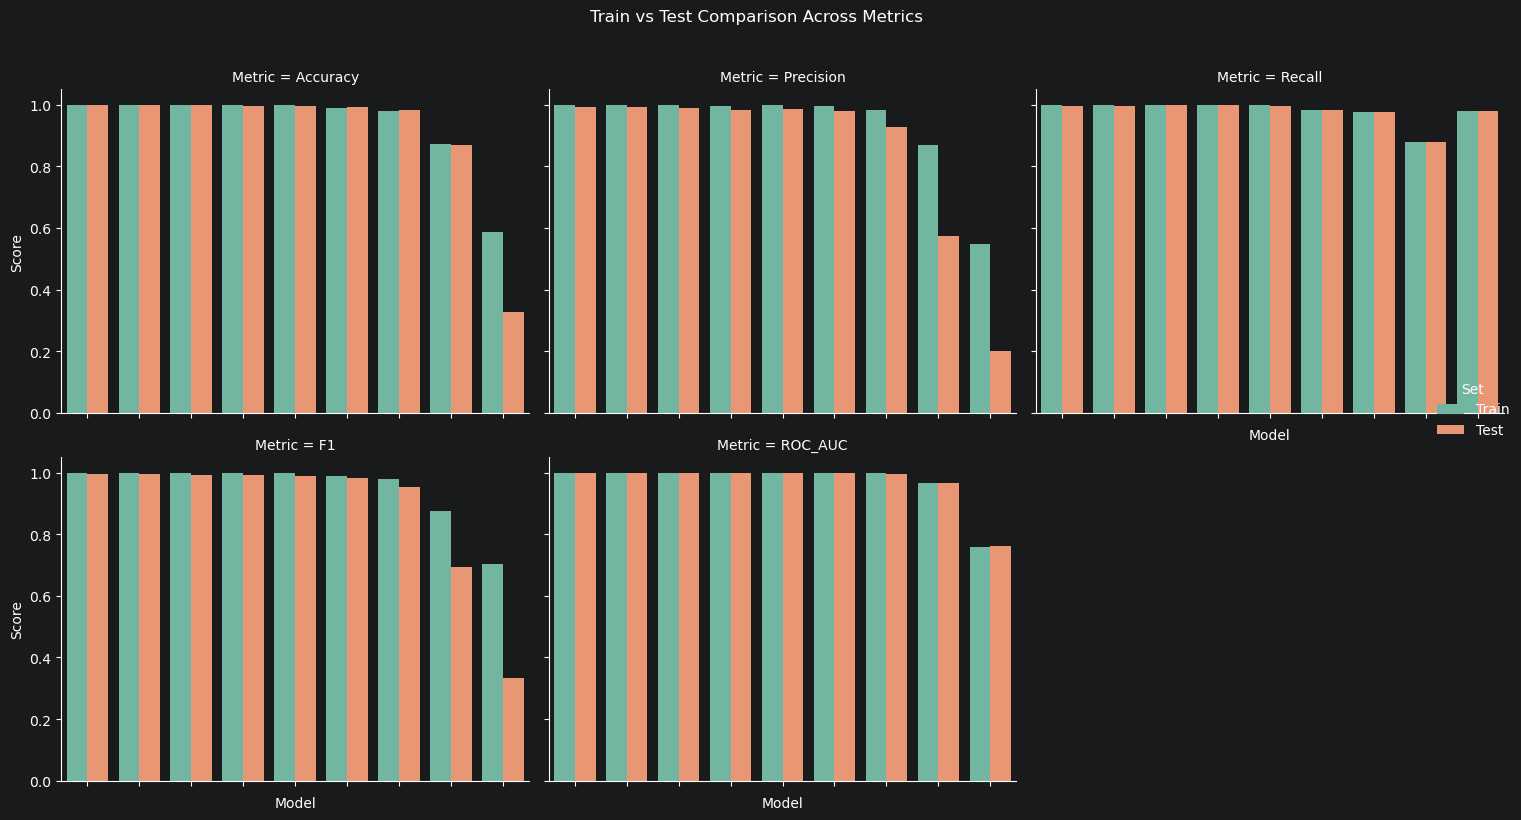

In [46]:
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
value_vars = [f"Train_{m}" for m in metric_names] + [f"Test_{m}" for m in metric_names]

metrics_melted = results_df.melt(
    id_vars="Model",
    value_vars=value_vars,
    var_name="Metric_Set",
    value_name="Score"
)
# Split "Train_Accuracy" -> Set="Train", Metric="Accuracy" (same value_vars naming used above)
metrics_melted[["Set", "Metric"]] = metrics_melted["Metric_Set"].str.split("_", n=1, expand=True)

g = sns.catplot(
    data=metrics_melted,
    kind="bar",
    x="Model", y="Score", hue="Set", col="Metric",
    col_wrap=3, height=4, aspect=1.2, palette="Set2"
)
g.set_xticklabels(rotation=45)
g.set_axis_labels("Model", "Score")
g.fig.suptitle("Train vs Test Comparison Across Metrics", y=1.02)
plt.tight_layout()
plt.show()


## Export artifacts for Streamlit deployment

In [ ]:
import joblib
import json
import os

os.makedirs("deployment_artifacts", exist_ok=True)

# XGBoost model trained earlier in the modeling loop
xgb_model = trained_models["XGBoost"]

joblib.dump(xgb_model, "deployment_artifacts/xgb_model.pkl")
joblib.dump(scaler, "deployment_artifacts/scaler.pkl")
joblib.dump(imputer, "deployment_artifacts/imputer.pkl")

with open("deployment_artifacts/selected_features.json", "w") as f:
    json.dump(list(selected_features), f)

with open("deployment_artifacts/non_negative_cols.json", "w") as f:
    json.dump(non_negative_cols, f)

print("Saved: xgb_model.pkl, scaler.pkl, imputer.pkl, selected_features.json, non_negative_cols.json")
print("Selected features count:", len(selected_features))
